In [3]:
import pickle
import os

folder = 'g_6000_ueV/field_no_loss_4ph'

path = os.path.join(folder,'data.pkl')

with open(path, "rb") as f:
    data = pickle.load(f)

z = data.pop('z')
t_samples = data.pop('t_samples')
num_data = len(data)
num_t = t_samples.size

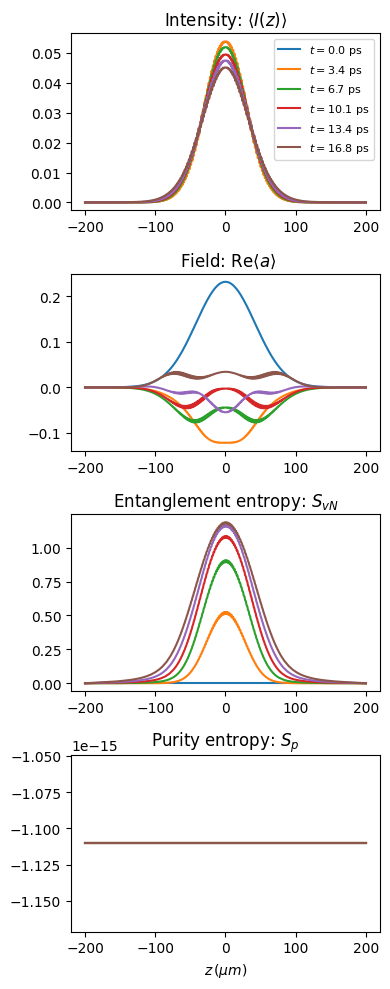

In [4]:
import matplotlib.pyplot as plt



fig, axs = plt.subplots(num_data,1, figsize=(4,10))

select_it = range(0, num_t, 2)
titles = [r'Intensity: $\langle I(z)\rangle$', r' Field: Re$\langle a \rangle$', r'Entanglement entropy: $S_{{vN}}$', r'Purity entropy: $S_p$']
for i, (ax, key) in enumerate(zip(axs, data)):
    ax.plot(z,data[key][:, select_it])
    ax.set_title(titles[i])

axs[0].legend([rf'$t={t:.1f}$ ps' for it, t in enumerate(t_samples) if it in select_it], fontsize=8)
axs[-1].set_xlabel(r'$z\,(\mu m)$')
plt.tight_layout()

In [6]:
data.keys()

dict_keys(['densities', 'a_expect', 'entanglement_entropy', 'purity_entropy'])

In [ ]:
import numpy as np
from qutip import *

# Hilbert space size
N = 50

# Parameters
alpha = 1.
r = 0.5
phi = 0.0
z = r * np.exp(1j * phi)
gamma = 0.5

# State
psi = displace(N, alpha) * squeeze(N, z) * basis(N, 0)

# Number operator
a = destroy(N)
ad = create(N)
n_op = a.dag() * a

# altered states (Kraus ops K0 and K1)
K0 = ((np.log(1 - gamma) / 2) * n_op).expm()
K1 = np.sqrt(gamma) * K0 @ a
psi_0_nn = (K0 @ psi)
psi_1_nn = (K1 @ psi)

norm_0, norm_1 = psi_0_nn.norm(), psi_1_nn.norm()
psi_0, psi_1 = psi_0_nn.unit(), psi_1_nn.unit()

# Expectations
n_mean = expect(n_op, psi)
n2_mean = expect(n_op**2, psi)

n_mean_0 = expect(n_op, psi_0)
n2_mean_0 = expect(n_op**2, psi_0)

n_mean_1 = expect(n_op, psi_1)
n2_mean_1 = expect(n_op**2, psi_1)

n_mean_diss = (norm_0 ** 2 * n_mean_0 + norm_1 ** 2 * n_mean_1) / (norm_0 ** 2 + norm_1 ** 2)
n2_mean_diss = (norm_0 ** 2 * n2_mean_0 + norm_1 ** 2 * n2_mean_1) / (norm_0 ** 2 + norm_1 ** 2)


print("<n> =", n_mean)
print("<n^2> =", n2_mean)
print(f"g2_u={(n2_mean-n_mean)/n_mean**2}\n")

print(f"g2_0={(n2_mean_0-n_mean_0)/n_mean_0**2}")
print(f"g2_1={(n2_mean_1-n_mean_1)/n_mean_1**2}\n")

print(f"g2_diss={(n2_mean_diss-n_mean_diss)/n_mean_diss**2}")


<n> = 1.2715403174076205
<n^2> = 2.6752431427354164
g2_u=0.8681902489632354

g2_0=0.6518436164631363
g2_1=0.7985281053856094

g2_diss=0.7160615102351268


In [ ]:
norm_0 ** 2 + norm_1 ** 2

0.9954006284068078

In [ ]:
K0.dag() @ K0 + K1.dag() @ K1

Quantum object: dims=[[50], [50]], shape=(50, 50), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1.         0.         0.         ... 0.         0.         0.        ]
 [0.         1.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.99       ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.04398894 0.         0.        ]
 [0.         0.         0.         ... 0.         0.04029701 0.        ]
 [0.         0.         0.         ... 0.         0.         0.03690358]]

In [ ]:
!{sys.executable} -m pip install qutip

  Using cached qutip-5.2.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
Using cached qutip-5.2.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (32.0 MB)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import sys
!{sys.executable} -m pip freeze

asttokens==3.0.1
comm==0.2.3
contourpy==1.3.2
cycler==0.12.1
debugpy==1.8.17
decorator==5.2.1
exceptiongroup==1.3.0
executing==2.2.1
filelock==3.19.1
fonttools==4.60.1
fsspec==2025.9.0
ipykernel==7.1.0
ipython==8.37.0
jedi==0.19.2
Jinja2==3.1.6
jupyter_client==8.6.3
jupyter_core==5.9.1
kiwisolver==1.4.9
MarkupSafe==2.1.5
matplotlib==3.10.7
matplotlib-inline==0.2.1
mpmath==1.3.0
nest-asyncio==1.6.0
networkx==3.3
numpy==2.2.6
nvidia-cublas-cu12==12.6.4.1
nvidia-cuda-cupti-cu12==12.6.80
nvidia-cuda-nvrtc-cu12==12.6.77
nvidia-cuda-runtime-cu12==12.6.77
nvidia-cudnn-cu12==9.10.2.21
nvidia-cufft-cu12==11.3.0.4
nvidia-cufile-cu12==1.11.1.6
nvidia-curand-cu12==10.3.7.77
nvidia-cusolver-cu12==11.7.1.2
nvidia-cusparse-cu12==12.5.4.2
nvidia-cusparselt-cu12==0.7.1
nvidia-nccl-cu12==2.27.5
nvidia-nvjitlink-cu12==12.6.85
nvidia-nvshmem-cu12==3.3.20
nvidia-nvtx-cu12==12.6.77
packaging==25.0
parso==0.8.5
pexpect==4.9.0
pillow==11.3.0
platformdirs==4.5.0
prompt_toolkit==3.0.52
psutil==7.1.3
ptyprocess=